# Data Augmentation Pipeline — Yogita Alone (CS24D017)


**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Load CIFAR-10 dataset, build augmented and baseline transforms.

## Step 1: Install & Import Libraries

In [2]:
!pip install torch torchvision matplotlib --quiet

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Step 2: Define Transforms

Two versions: one WITH augmentation (rotation, flip, crop), one WITHOUT (baseline) — needed for comparison later.

In [3]:
# Augmented transform: rotation + horizontal flip + random crop
augmented_transform = transforms.Compose([
    transforms.RandomRotation(15),             # rotate randomly between -15 and +15 degrees
    transforms.RandomHorizontalFlip(p=0.5),     # 50% chance of horizontal flip
    transforms.RandomCrop(32, padding=4),       # pad then randomly crop back to 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Baseline transform: no augmentation, just tensor + normalize
baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Transforms defined successfully.")

Transforms defined successfully.


## Step 3: Load CIFAR-10 Dataset

Downloads automatically (~170MB) — no manual dataset download needed.

In [5]:
train_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=augmented_transform)
train_base = datasets.CIFAR10(root='./data', train=True, download=True, transform=baseline_transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=baseline_transform)

print(f"Full training set size: {len(train_aug)}")
print(f"Test set size: {len(test_set)}")

100%|██████████| 170M/170M [43:18<00:00, 65.6kB/s]


Full training set size: 50000
Test set size: 10000


## Step 4: Take a Small Subset

Using a small subset (2000 images) makes the model overfit faster on the baseline — which is exactly what we want to demonstrate augmentation fixing.

In [6]:
SUBSET_SIZE = 2000

train_aug = torch.utils.data.Subset(train_aug, range(SUBSET_SIZE))
train_base = torch.utils.data.Subset(train_base, range(SUBSET_SIZE))

print(f"Using subset of {SUBSET_SIZE} images for training.")

Using subset of 2000 images for training.


## Step 5: Create DataLoaders

These three loaders (`loader_aug`, `loader_base`, `test_loader`) are the final output.

In [7]:
loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True)
loader_base = DataLoader(train_base, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print("DataLoaders ready: loader_aug, loader_base, test_loader")

DataLoaders ready: loader_aug, loader_base, test_loader


## Step 6: Verify Augmentation Visually

Save a sample image to show the augmentation is actually working.

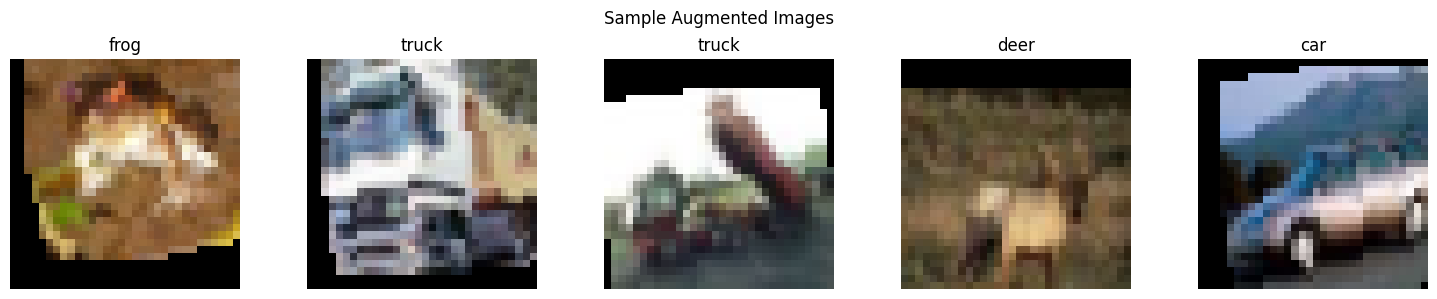

Saved sample_augmented.png — use this in the README/report.


In [8]:
 classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_aug[i]
    img_display = img.permute(1, 2, 0) * 0.5 + 0.5  # unnormalize for display
    axes[i].imshow(img_display)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.suptitle('Sample Augmented Images')
plt.tight_layout()
plt.savefig('sample_augmented.png')
plt.show()

print("Saved sample_augmented.png — use this in the README/report.")

# CNN Model + Training — Srushti Belsare (CS23165)

**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Build CNN architecture, train baseline and augmented models, and save training results.

CNN Architecture

In [9]:
# Step 7: Build CNN Model

import torch.nn as nn
import torch.optim as optim

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution + ReLU + Pooling
        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Flatten + Dense Layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 32x32 -> 16x16 -> 8x8 -> 4x4
            nn.Linear(128 * 4 * 4, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = CNNModel().to(device)

print(model)

Using device: cpu
CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [10]:
# Step 8: Training Function

def train_model(model, train_loader, epochs=20):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    train_accuracies = []

    model.to(device)

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    return train_losses, train_accuracies

In [11]:
 # Step 9: Train Baseline Model (Without Augmentation)

baseline_model = CNNModel().to(device)

baseline_losses, baseline_accuracies = train_model(
    baseline_model,
    loader_base,
    epochs=20
)

print("Baseline training completed.")

Epoch [1/20] Loss: 2.1439 Accuracy: 21.05%
Epoch [2/20] Loss: 1.8335 Accuracy: 33.40%
Epoch [3/20] Loss: 1.6747 Accuracy: 39.90%
Epoch [4/20] Loss: 1.5475 Accuracy: 42.45%
Epoch [5/20] Loss: 1.4570 Accuracy: 47.60%
Epoch [6/20] Loss: 1.3215 Accuracy: 52.40%
Epoch [7/20] Loss: 1.2461 Accuracy: 56.35%
Epoch [8/20] Loss: 1.1669 Accuracy: 58.55%
Epoch [9/20] Loss: 1.0476 Accuracy: 63.60%
Epoch [10/20] Loss: 0.9651 Accuracy: 66.35%
Epoch [11/20] Loss: 0.8457 Accuracy: 70.80%
Epoch [12/20] Loss: 0.7742 Accuracy: 72.40%
Epoch [13/20] Loss: 0.6639 Accuracy: 77.50%
Epoch [14/20] Loss: 0.5333 Accuracy: 82.00%
Epoch [15/20] Loss: 0.5021 Accuracy: 82.85%
Epoch [16/20] Loss: 0.4777 Accuracy: 84.45%
Epoch [17/20] Loss: 0.2846 Accuracy: 91.20%
Epoch [18/20] Loss: 0.1888 Accuracy: 95.00%
Epoch [19/20] Loss: 0.1416 Accuracy: 96.45%
Epoch [20/20] Loss: 0.1657 Accuracy: 96.00%
Baseline training completed.


In [12]:
# Step 10: Train Augmented Model

augmented_model = CNNModel().to(device)

augmented_losses, augmented_accuracies = train_model(
    augmented_model,
    loader_aug,
    epochs=20
)

print("Augmented training completed.")

Epoch [1/20] Loss: 2.2107 Accuracy: 18.25%
Epoch [2/20] Loss: 2.0262 Accuracy: 24.75%
Epoch [3/20] Loss: 1.9262 Accuracy: 28.65%
Epoch [4/20] Loss: 1.8241 Accuracy: 32.90%
Epoch [5/20] Loss: 1.7468 Accuracy: 34.75%
Epoch [6/20] Loss: 1.6927 Accuracy: 37.75%
Epoch [7/20] Loss: 1.6137 Accuracy: 39.30%
Epoch [8/20] Loss: 1.5603 Accuracy: 40.90%
Epoch [9/20] Loss: 1.5545 Accuracy: 40.90%
Epoch [10/20] Loss: 1.5057 Accuracy: 44.90%
Epoch [11/20] Loss: 1.4366 Accuracy: 47.15%
Epoch [12/20] Loss: 1.4523 Accuracy: 44.85%
Epoch [13/20] Loss: 1.4143 Accuracy: 47.10%
Epoch [14/20] Loss: 1.3779 Accuracy: 47.90%
Epoch [15/20] Loss: 1.3662 Accuracy: 49.60%
Epoch [16/20] Loss: 1.3139 Accuracy: 52.45%
Epoch [17/20] Loss: 1.3081 Accuracy: 51.95%
Epoch [18/20] Loss: 1.2930 Accuracy: 52.70%
Epoch [19/20] Loss: 1.3013 Accuracy: 51.80%
Epoch [20/20] Loss: 1.2569 Accuracy: 53.90%
Augmented training completed.


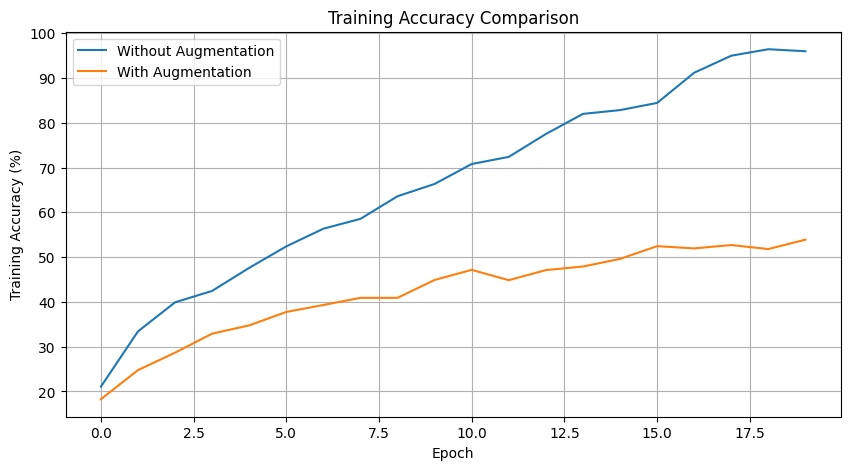

In [13]:
# Step 11: Compare Training Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    baseline_accuracies,
    label="Without Augmentation"
)

plt.plot(
    augmented_accuracies,
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.grid(True)
plt.show()

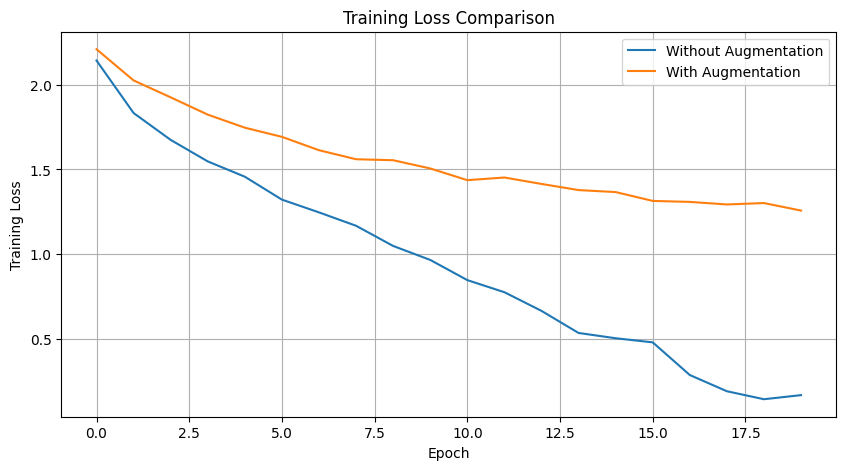

In [14]:
# Step 12: Compare Training Loss

plt.figure(figsize=(10, 5))

plt.plot(
    baseline_losses,
    label="Without Augmentation"
)

plt.plot(
    augmented_losses,
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Step 13: Evaluation Function

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [16]:
# Step 14: Test Accuracy Comparison

baseline_test_accuracy = evaluate_model(
    baseline_model,
    test_loader
)

augmented_test_accuracy = evaluate_model(
    augmented_model,
    test_loader
)

print(f"Baseline Test Accuracy: {baseline_test_accuracy:.2f}%")
print(f"Augmented Test Accuracy: {augmented_test_accuracy:.2f}%")

Baseline Test Accuracy: 47.92%
Augmented Test Accuracy: 47.68%


In [17]:
# Step 15: Final Comparison

print("\n===== FINAL RESULTS =====")

print(
    f"Without Augmentation : "
    f"{baseline_test_accuracy:.2f}%"
)

print(
    f"With Augmentation    : "
    f"{augmented_test_accuracy:.2f}%"
)

improvement = augmented_test_accuracy - baseline_test_accuracy

print(
    f"Improvement          : "
    f"{improvement:.2f}%"
)


===== FINAL RESULTS =====
Without Augmentation : 47.92%
With Augmentation    : 47.68%
Improvement          : -0.24%


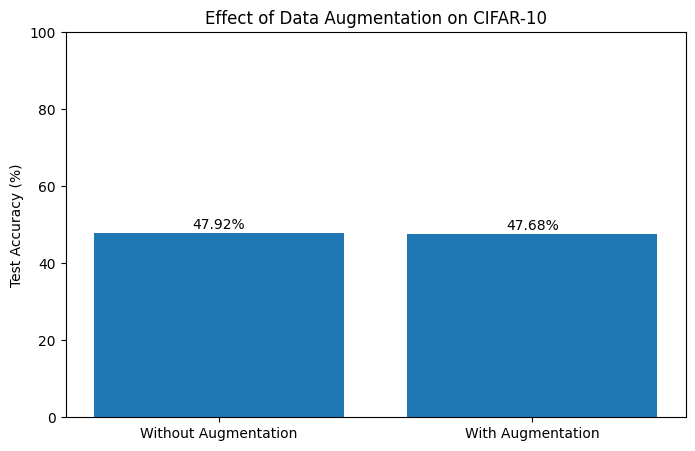

In [18]:
# Step 16: Accuracy Comparison Graph

methods = [
    "Without Augmentation",
    "With Augmentation"
]

accuracies = [
    baseline_test_accuracy,
    augmented_test_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(methods, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Data Augmentation on CIFAR-10")

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

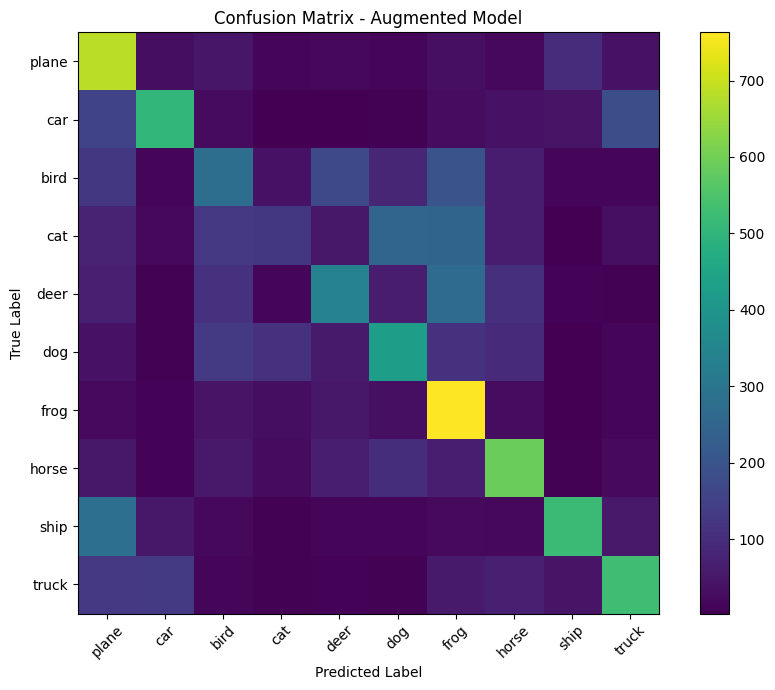

In [19]:
# Step 17: Confusion Matrix for Augmented Model

import numpy as np

classes = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

augmented_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = augmented_model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


conf_matrix = np.zeros((10, 10), dtype=int)

for true_label, predicted_label in zip(
    all_labels,
    all_predictions
):
    conf_matrix[true_label, predicted_label] += 1


plt.figure(figsize=(9, 7))

plt.imshow(conf_matrix)

plt.colorbar()

plt.xticks(
    range(10),
    classes,
    rotation=45
)

plt.yticks(
    range(10),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Augmented Model")

plt.tight_layout()
plt.show()

## Step 18: Conclusion

The CIFAR-10 dataset was trained using two approaches:

1. Without data augmentation
2. With rotation, horizontal flipping and random cropping

The training and testing results were compared to study the effect of data augmentation on overfitting.

Data augmentation creates different variations of training images and helps the model learn more general features. Therefore, it can improve generalization and reduce the risk of overfitting.

Overfitting analysis + result — Shinam Sheikh (CS24D010)
Project: Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

My part: Build CNN architecture, train baseline and augmented models, and save training results.



# overfitting analysis + results— Shinam Sheikh (CS24D010)

**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Overfitting Analysis + Results — compare training/validation performance with and without data augmentation, calculate test accuracy, analyze overfitting, create comparison graphs/table, and write the conclusion.

In [34]:


from torch.utils.data import random_split, DataLoader

# We currently have 2000 training images
TRAIN_SIZE = 1600
VAL_SIZE = 400

# Same random split for fair comparison
generator1 = torch.Generator().manual_seed(42)

train_base_split, val_base_split = random_split(
    train_base,
    [TRAIN_SIZE, VAL_SIZE],
    generator=generator1
)

generator2 = torch.Generator().manual_seed(42)

train_aug_split, val_aug_split = random_split(
    train_aug,
    [TRAIN_SIZE, VAL_SIZE],
    generator=generator2
)

# Training DataLoaders
loader_base_m3 = DataLoader(
    train_base_split,
    batch_size=64,
    shuffle=True
)

loader_aug_m3 = DataLoader(
    train_aug_split,
    batch_size=64,
    shuffle=True
)

# Validation DataLoader
# Validation images are NOT augmented
val_loader = DataLoader(
    val_base_split,
    batch_size=64,
    shuffle=False
)

print("===== MEMBER 3 DATA SPLIT =====")
print("Training images   :", TRAIN_SIZE)
print("Validation images :", VAL_SIZE)
print("Test images       :", len(test_loader.dataset))

===== MEMBER 3 DATA SPLIT =====
Training images   : 1600
Validation images : 400
Test images       : 10000


In [41]:


def train_model_with_validation(
    model,
    train_loader,
    val_loader,
    epochs=20
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    train_accuracies = []

    val_losses = []
    val_accuracies = []

    model.to(device)

    for epoch in range(epochs):

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        model.train()

        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            train_total += labels.size(0)

            train_correct += (
                predicted == labels
            ).sum().item()

        train_loss = (
            running_train_loss / len(train_loader)
        )

        train_accuracy = (
            100 * train_correct / train_total
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss = (
            running_val_loss / len(val_loader)
        )

        val_accuracy = (
            100 * val_correct / val_total
        )

        # Save results
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch [{epoch+1:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    return (
        train_losses,
        train_accuracies,
        val_losses,
        val_accuracies
    )

In [36]:


baseline_model_m3 = CNNModel().to(device)

(
    baseline_train_losses,
    baseline_train_accuracies,
    baseline_val_losses,
    baseline_val_accuracies
) = train_model_with_validation(
    baseline_model_m3,
    loader_base_m3,
    val_loader,
    epochs=20
)

print("\nBaseline model training completed.")

Epoch [01/20] | Train Loss: 2.1758 | Train Acc: 19.75% | Val Loss: 2.0182 | Val Acc: 26.25%
Epoch [02/20] | Train Loss: 1.9219 | Train Acc: 29.31% | Val Loss: 1.8667 | Val Acc: 33.75%
Epoch [03/20] | Train Loss: 1.7477 | Train Acc: 35.25% | Val Loss: 1.7444 | Val Acc: 37.25%
Epoch [04/20] | Train Loss: 1.6346 | Train Acc: 40.06% | Val Loss: 1.6557 | Val Acc: 38.75%
Epoch [05/20] | Train Loss: 1.5356 | Train Acc: 42.25% | Val Loss: 1.6815 | Val Acc: 38.50%
Epoch [06/20] | Train Loss: 1.4242 | Train Acc: 48.44% | Val Loss: 1.6287 | Val Acc: 38.50%
Epoch [07/20] | Train Loss: 1.3426 | Train Acc: 50.62% | Val Loss: 1.5327 | Val Acc: 45.25%
Epoch [08/20] | Train Loss: 1.2337 | Train Acc: 55.75% | Val Loss: 1.5300 | Val Acc: 46.00%
Epoch [09/20] | Train Loss: 1.1536 | Train Acc: 59.62% | Val Loss: 1.5681 | Val Acc: 46.75%
Epoch [10/20] | Train Loss: 1.0665 | Train Acc: 62.88% | Val Loss: 1.5999 | Val Acc: 45.25%
Epoch [11/20] | Train Loss: 0.9814 | Train Acc: 64.38% | Val Loss: 1.6115 | Val 

In [37]:

augmented_model_m3 = CNNModel().to(device)

(
    augmented_train_losses,
    augmented_train_accuracies,
    augmented_val_losses,
    augmented_val_accuracies
) = train_model_with_validation(
    augmented_model_m3,
    loader_aug_m3,
    val_loader,
    epochs=20
)

print("\nAugmented model training completed.")

Epoch [01/20] | Train Loss: 2.2519 | Train Acc: 14.62% | Val Loss: 2.1318 | Val Acc: 22.25%
Epoch [02/20] | Train Loss: 2.0836 | Train Acc: 22.31% | Val Loss: 1.9928 | Val Acc: 27.00%
Epoch [03/20] | Train Loss: 1.9728 | Train Acc: 27.19% | Val Loss: 1.8893 | Val Acc: 31.50%
Epoch [04/20] | Train Loss: 1.8649 | Train Acc: 31.00% | Val Loss: 1.7808 | Val Acc: 33.50%
Epoch [05/20] | Train Loss: 1.7591 | Train Acc: 34.00% | Val Loss: 1.6869 | Val Acc: 39.25%
Epoch [06/20] | Train Loss: 1.7154 | Train Acc: 37.06% | Val Loss: 1.6928 | Val Acc: 37.25%
Epoch [07/20] | Train Loss: 1.7000 | Train Acc: 37.25% | Val Loss: 1.6318 | Val Acc: 41.25%
Epoch [08/20] | Train Loss: 1.6168 | Train Acc: 40.00% | Val Loss: 1.5769 | Val Acc: 42.25%
Epoch [09/20] | Train Loss: 1.5661 | Train Acc: 41.00% | Val Loss: 1.5795 | Val Acc: 43.25%
Epoch [10/20] | Train Loss: 1.5128 | Train Acc: 43.38% | Val Loss: 1.5868 | Val Acc: 39.75%
Epoch [11/20] | Train Loss: 1.5070 | Train Acc: 43.50% | Val Loss: 1.5257 | Val 

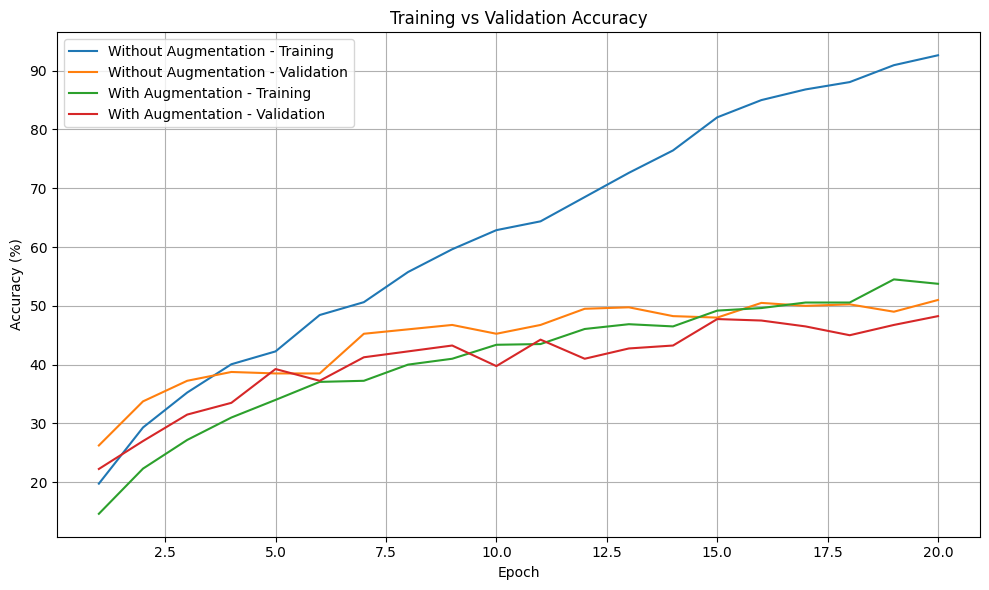

In [38]:

epochs = range(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_train_accuracies,
    label="Without Augmentation - Training"
)

plt.plot(
    epochs,
    baseline_val_accuracies,
    label="Without Augmentation - Validation"
)

plt.plot(
    epochs,
    augmented_train_accuracies,
    label="With Augmentation - Training"
)

plt.plot(
    epochs,
    augmented_val_accuracies,
    label="With Augmentation - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "member3_accuracy_comparison.png",
    dpi=300
)

plt.show()

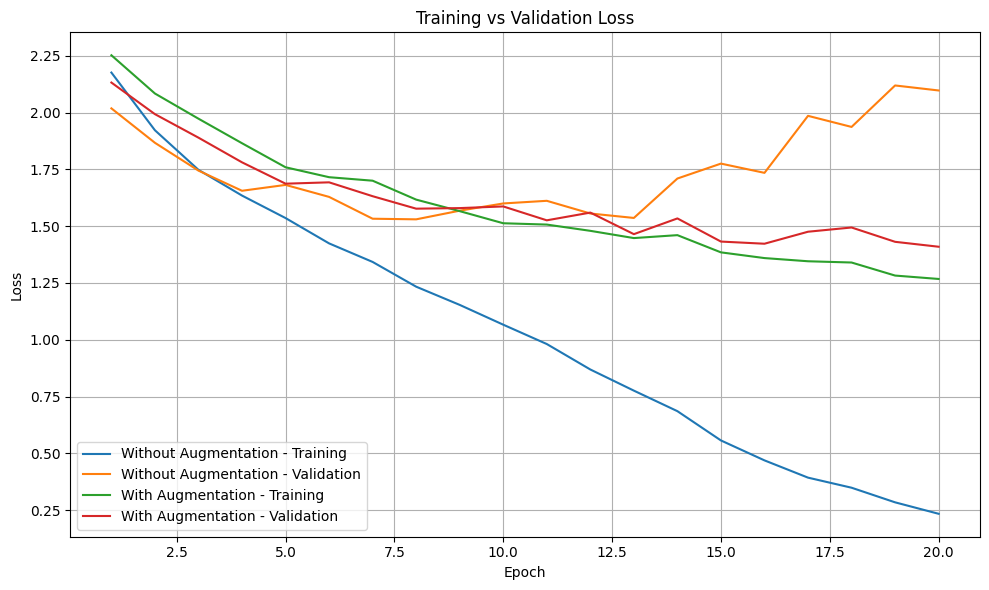

In [39]:


plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_train_losses,
    label="Without Augmentation - Training"
)

plt.plot(
    epochs,
    baseline_val_losses,
    label="Without Augmentation - Validation"
)

plt.plot(
    epochs,
    augmented_train_losses,
    label="With Augmentation - Training"
)

plt.plot(
    epochs,
    augmented_val_losses,
    label="With Augmentation - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "member3_loss_comparison.png",
    dpi=300
)

plt.show()

In [42]:




print(
    f"Without Augmentation Test Accuracy: "
    f"{baseline_test_m3:.2f}%"
)

print(
    f"With Augmentation Test Accuracy: "
    f"{augmented_test_m3:.2f}%"
)

print()

print(
    f"Without Augmentation Overfitting Gap: "
    f"{baseline_gap:.2f}%"
)

print(
    f"With Augmentation Overfitting Gap: "
    f"{augmented_gap:.2f}%"
)

print()

if augmented_gap < baseline_gap:

    print(
        "Conclusion: Data augmentation reduced the "
        "training-validation accuracy gap, indicating "
        "reduced overfitting."
    )

else:

    print(
        "Conclusion: In this experiment, the augmented "
        "model did not show a smaller final accuracy gap. "
        "The training and validation curves should be "
        "considered for further analysis."
    )

print()

if augmented_test_m3 > baseline_test_m3:

    print(
        "The augmented model achieved higher test accuracy, "
        "indicating better generalization on unseen data."
    )

else:

    print(
        "The augmented model did not achieve higher test "
        "accuracy in this experiment."
    )

print()

print(
    "Rotation, horizontal flipping and random cropping "
    "were applied to the training images to introduce "
    "variation and improve model generalization."
)

Without Augmentation Test Accuracy: 47.53%
With Augmentation Test Accuracy: 47.30%

Without Augmentation Overfitting Gap: 42.31%
With Augmentation Overfitting Gap: 5.12%

Conclusion: Data augmentation reduced the training-validation accuracy gap, indicating reduced overfitting.

The augmented model did not achieve higher test accuracy in this experiment.

Rotation, horizontal flipping and random cropping were applied to the training images to introduce variation and improve model generalization.
